---

# Label distrubution and analysis
> Oliver Jung

---

### Import Ontonotes5

In [66]:
import os
import random
from datasets import load_dataset

In [67]:
HF_TOKEN = os.getenv("HF_TOKEN")

ds_onto = load_dataset(
    "eriktks/conll2003", 
    revision="refs/convert/parquet", 
    token=HF_TOKEN
)

Generating train split: 14041 examples [00:00, 117771.73 examples/s]
Generating validation split: 3250 examples [00:00, 99730.68 examples/s]
Generating test split: 3453 examples [00:00, 115362.32 examples/s]


In [68]:
def print_random(ds, n=5, split="train"):
    """
    Print n random samples from the dataset.

    Args:
        ds: The dataset from which to sample.
        n: The number of samples (default is 5).
        split: The dataset split to sample from (default is "train").
    """
    for _ in range(n):
        idx = random.randint(0, len(ds[split]) - 1)
        sample = ds[split][idx]
        print(sample)

In [69]:
print_random(ds_onto)
print("Size of train split:", len(ds_onto["train"]))

{'id': '5033', 'tokens': ['Kilmarnock', '3', '1', '0', '2', '5', '7', '3'], 'pos_tags': [21, 11, 11, 11, 11, 11, 11, 11], 'chunk_tags': [11, 12, 12, 12, 12, 12, 12, 12], 'ner_tags': [3, 0, 0, 0, 0, 0, 0, 0]}
{'id': '4832', 'tokens': ['1.', 'Slight', '280', 'points'], 'pos_tags': [11, 21, 11, 24], 'chunk_tags': [11, 12, 12, 12], 'ner_tags': [0, 1, 0, 0]}
{'id': '11068', 'tokens': ['India', 'scored', '226', 'for', 'five', 'wickets', 'in', 'their', '50', 'overs', 'against', 'Sri', 'Lanka', 'in', 'the', 'second', 'day-night', 'limited', 'overs', 'match', 'of', 'the', 'Singer', 'World', 'Series', 'tournament', 'on', 'Wednesday', '.'], 'pos_tags': [22, 38, 11, 15, 11, 24, 15, 29, 11, 24, 15, 22, 22, 15, 12, 16, 16, 16, 24, 41, 15, 12, 22, 22, 22, 21, 15, 22, 7], 'chunk_tags': [11, 21, 11, 13, 11, 12, 13, 11, 12, 12, 13, 11, 12, 13, 11, 12, 12, 12, 12, 21, 13, 11, 12, 12, 12, 12, 13, 11, 0], 'ner_tags': [5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 8, 0, 0, 0, 0]}
{

### for debugging

In [71]:
print(ds_onto)
print(ds_onto["train"].column_names)
print(ds_onto["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags']
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


### OntoNotes Labels extrahieren

In [72]:
from collections import Counter
import numpy as np

onto_counter = Counter()
onto_lengths = []

for row in ds_onto["train"]:

    tags = row["ner_tags"]

    labels_in_sentence = []

    for tag in tags:

        if tag == "O":
            continue

        if isinstance(tag, int):
            tag = ds_onto["train"].features["ner_tags"].feature.names[tag]

        label = tag.replace("B-", "").replace("I-", "")

        labels_in_sentence.append(label)

    if labels_in_sentence:
        onto_counter.update(set(labels_in_sentence))
        onto_lengths.append(len(set(labels_in_sentence)))

onto_lengths = np.array(onto_lengths)

### Ontonotes Labels zählen

In [73]:
from collections import Counter

onto_counter = Counter()

for row in ds_onto["train"]:
    for label in row["ner_tags"]:
        onto_counter[label] += 1

print("Number of unique labels:", len(onto_counter))
print("Top 20 labels:")
print(onto_counter.most_common(20))

Number of unique labels: 9
Top 20 labels:
[(0, 169578), (5, 7140), (1, 6600), (3, 6321), (2, 4528), (4, 3704), (7, 3438), (6, 1157), (8, 1155)]


### Labelverteilung plotten OntoNotes

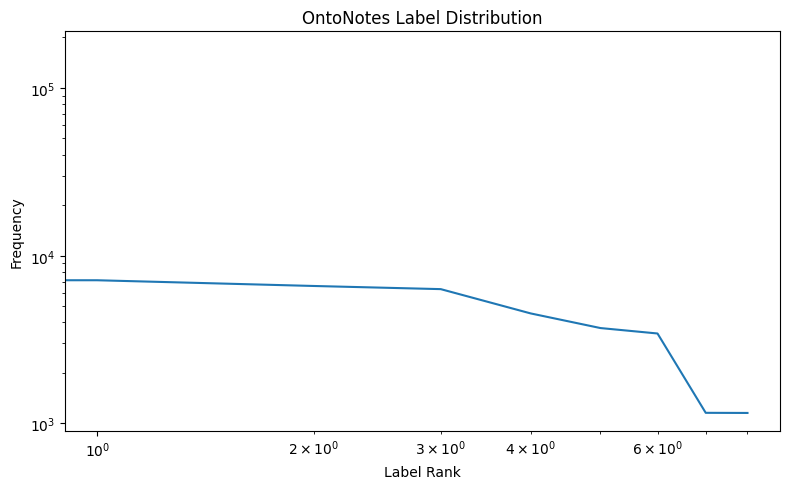

In [74]:
import matplotlib.pyplot as plt

values = sorted(onto_counter.values(), reverse=True)

plt.figure(figsize=(8,5))
plt.plot(values)

plt.xscale("log")
plt.yscale("log")

plt.title("OntoNotes Label Distribution")
plt.xlabel("Label Rank")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("ontonotes_label_distribution.png", dpi=300)

plt.show()

### Long Tail analyse OntoNotes

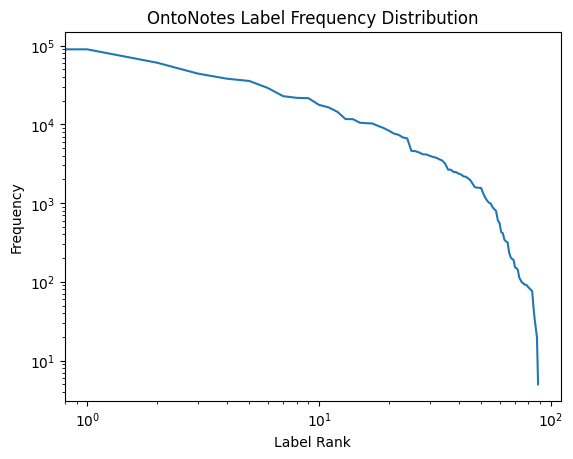

In [79]:
import matplotlib.pyplot as plt

values = sorted(label_counter.values(), reverse=True)

plt.figure()
plt.plot(values)
plt.xscale("log")
plt.yscale("log")
plt.title("OntoNotes Label Frequency Distribution")
plt.xlabel("Label Rank")
plt.ylabel("Frequency")
plt.show()

In [80]:
from collections import Counter
import numpy as np

onto_counter = Counter()
mention_lengths = []
mentions = []

label_names = ds_onto["train"].features["ner_tags"].feature.names

for row in ds_onto["train"]:

    tokens = row["tokens"]
    tags = row["ner_tags"]

    current_tokens = []
    current_label = None

    for token, tag in zip(tokens, tags):

        tag = label_names[tag]

        if tag.startswith("B-"):

            if current_tokens:
                mention = " ".join(current_tokens)
                mentions.append((mention, current_label))
                onto_counter[current_label] += 1
                mention_lengths.append(1)

            current_label = tag[2:]
            current_tokens = [token]

        elif tag.startswith("I-"):

            current_tokens.append(token)

        else:

            if current_tokens:
                mention = " ".join(current_tokens)
                mentions.append((mention, current_label))
                onto_counter[current_label] += 1
                mention_lengths.append(1)

                current_tokens = []
                current_label = None

    if current_tokens:
        mention = " ".join(current_tokens)
        mentions.append((mention, current_label))
        onto_counter[current_label] += 1
        mention_lengths.append(1)

### Durchschnittliche Labels pro Mention

In [84]:
print("Average labels per mention:", np.mean(mention_lengths))
print("Max labels per mention:", np.max(mention_lengths))

Average labels per mention: 1.0
Max labels per mention: 1


In [91]:
print(onto_counter.most_common(20))

[('LOC', 7140), ('PER', 6600), ('ORG', 6321), ('MISC', 3438)]


### Häufigste Mentions OntoNotes

In [92]:
print("Top 10 labels:")
print(onto_counter.most_common(20))

#for i in range(20):
#    print(ds_onto["train"][i]["mention_span"], ds_onto["train"][i]["ner_tags"])

Top 10 labels:
[('LOC', 7140), ('PER', 6600), ('ORG', 6321), ('MISC', 3438)]


### Import Data from FIGER

In [22]:
#dataset.save_to_disk("datasets/figer_hf")

from datasets import load_dataset

figer = load_dataset("DGME/figer")

figer.save_to_disk("/home/oli/ml_project/NERC/datasets/figer_hf")

Saving the dataset (1/1 shards): 100%|██████████| 563/563 [00:00<00:00, 86166.51 examples/s]


### Für Debuging

In [28]:
print(figer)
print(figer["train"].column_names)
print(figer["train"][0])

DatasetDict({
    train: Dataset({
        features: ['mention_span', 'left_context_token', 'right_context_token', 'y_str'],
        num_rows: 2690286
    })
    test: Dataset({
        features: ['mention_span', 'left_context_token', 'right_context_token', 'y_str'],
        num_rows: 563
    })
})
['mention_span', 'left_context_token', 'right_context_token', 'y_str']
{'mention_span': 'Muddy Waters', 'left_context_token': ['It', 'includes', 'a', 'cover', 'of', '"', 'Low', 'Rider', '"', 'by', 'War', 'and', 'a', 'reworking', 'of'], 'right_context_token': ["'", '"', 'I', 'Just', 'Wanna', 'Make', 'Love', 'To', 'You', '"', 'as', '"', 'I', 'Just', 'Wanna', 'Get', 'High', 'with', 'You', '"', '.'], 'y_str': ['/person/musician', '/person/actor', '/person/artist', '/person']}


### FIGER Labels zählen:

In [29]:
from collections import Counter

label_counter = Counter()

for row in figer["train"]:
    for label in row["y_str"]:
        label_counter[label] += 1

print("Number of unique labels:", len(label_counter))
print("Top 20 labels:")
print(label_counter.most_common(20))

Number of unique labels: 128
Top 20 labels:
[('/location', 1128854), ('/person', 730364), ('/organization', 470747), ('/location/city', 371977), ('/person/artist', 257720), ('/location/country', 255980), ('/person/author', 199900), ('/person/actor', 187953), ('/organization/company', 147030), ('/event', 134486), ('/government', 126850), ('/organization/sports_team', 110675), ('/government/government', 102023), ('/person/athlete', 98375), ('/title', 95474), ('/location/cemetery', 91840), ('/person/musician', 87168), ('/location/province', 86603), ('/building', 82606), ('/language', 76442)]


### LONG Tail Analyse FIGER

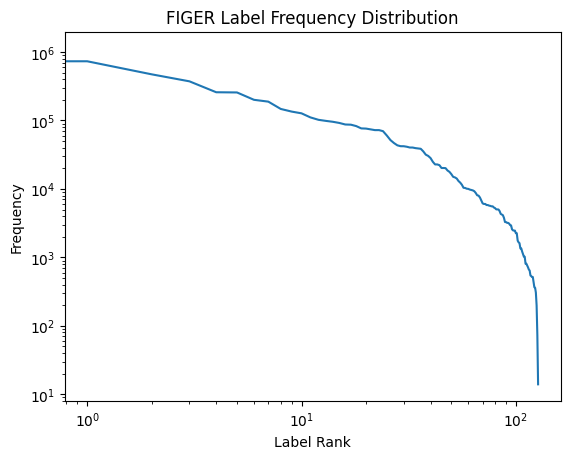

In [31]:
import matplotlib.pyplot as plt

values = sorted(label_counter.values(), reverse=True)

plt.figure()
plt.plot(values)
plt.xscale("log")
plt.yscale("log")
plt.title("FIGER Label Frequency Distribution")
plt.xlabel("Label Rank")
plt.ylabel("Frequency")
plt.show()

### Durchschnittliche Labels pro Mention FIGER

In [ ]:
label_counts = figer["train"]["y_str"]

lengths = [len(x) for x in label_counts]

print("Average labels per mention:", sum(lengths)/len(lengths))
print("Max labels per mention:", max(lengths))

Average labels per mention: 2.385152730973584
Max labels per mention: 10


### Häufigste Mentions FIGER

In [37]:
for i in range(20):
    print(figer["train"][i]["mention_span"], figer["train"][i]["y_str"])

Muddy Waters ['/person/musician', '/person/actor', '/person/artist', '/person']
Mayo Clinic ['/organization', '/organization/company', '/building/hospital', '/building', '/location']
Sumatra ['/geography', '/location', '/geography/island']
Locomotion No. 1 ['/train']
Robert Stephenson and Company ['/organization', '/organization/company']
Stockton and Darlington Railway ['/rail/railway', '/organization', '/organization/company', '/rail', '/location']
R ['/person/director', '/person']
Floria Sigismondi ['/person/artist', '/person/director', '/person/author', '/person']
Out Hud ['/person/musician', '/person/artist', '/person']
LCD Soundsystem ['/person/musician', '/person/artist', '/person']
Cake ['/person/musician', '/person/artist', '/person']
Maserati ['/person/musician', '/person/artist', '/person']
Turing Machine ['/person/musician', '/person/artist', '/person']
The Juan MacLean ['/person/artist', '/person']
Mosfellsbær ['/location/city', '/location']
Mandarin Chinese ['/language']


### Get Data Lokal

In [25]:
from datasets import load_from_disk

figer = load_from_disk("/home/oli/ml_project/NERC/datasets/figer_hf")

### Import Data for Ultra Fine

In [19]:
from datasets import load_dataset

ultrafine = load_dataset(
    "json",
    data_files={
        "train": "/home/oli/ml_project/NERC/datasets/ultra_fine/crowd/train.json",
        "dev": "/home/oli/ml_project/NERC/datasets/ultra_fine/crowd/dev.json",
        "test": "/home/oli/ml_project/NERC/datasets/ultra_fine/crowd/test.json",
    }
)

ultrafine.save_to_disk("/home/oli/ml_project/NERC/datasets/ultrafine_hf")

Saving the dataset (1/1 shards): 100%|██████████| 1998/1998 [00:00<00:00, 66054.11 examples/s]


### Debugging

In [34]:
print(ultrafine) 
print(ultrafine["train"].column_names)
print(ultrafine["train"][0])

DatasetDict({
    train: Dataset({
        features: ['annot_id', 'mention_span', 'right_context_token', 'y_str', 'left_context_token'],
        num_rows: 1998
    })
    dev: Dataset({
        features: ['annot_id', 'mention_span', 'right_context_token', 'y_str', 'left_context_token'],
        num_rows: 1998
    })
    test: Dataset({
        features: ['annot_id', 'mention_span', 'right_context_token', 'y_str', 'left_context_token'],
        num_rows: 1998
    })
})
['annot_id', 'mention_span', 'right_context_token', 'y_str', 'left_context_token']
{'annot_id': 'APW_ENG_20101103.0611:12:2', 'mention_span': 'Web users', 'right_context_token': ['to', 'locate', 'its', 'address', 'using', 'Google', 'Maps', '.'], 'y_str': ['citizen', 'person', 'user'], 'left_context_token': ['The', 'British', 'Information', 'Commissioner', "'s", 'Office', 'invites']}


### Ultra Fine Labels Zählen

In [35]:
from collections import Counter

label_counter = Counter()

for row in ultrafine["train"]:
    for label in row["y_str"]:
        label_counter[label] += 1

print("Number of unique labels:", len(label_counter))
print("Top 20 labels:")
print(label_counter.most_common(20))

Number of unique labels: 1639
Top 20 labels:
[('person', 824), ('organization', 248), ('adult', 194), ('leader', 181), ('event', 181), ('male', 167), ('object', 160), ('place', 156), ('group', 152), ('location', 131), ('politician', 122), ('area', 122), ('administration', 110), ('man', 109), ('official', 99), ('company', 93), ('country', 92), ('region', 89), ('government', 84), ('nation', 79)]


### Long-Tail Analyse Ultra Fine

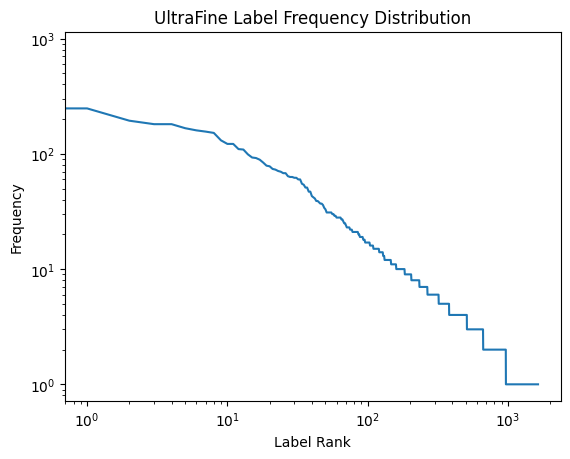

In [36]:
import matplotlib.pyplot as plt

values = sorted(label_counter.values(), reverse=True)

plt.figure()
plt.plot(values)
plt.xscale("log")
plt.yscale("log")
plt.title("UltraFine Label Frequency Distribution")
plt.xlabel("Label Rank")
plt.ylabel("Frequency")
plt.show()

### Durchschnittliche Anzahl der Labels Ultra Fine

In [40]:
label_counts = ultrafine["train"]["y_str"]

lengths = [len(x) for x in label_counts]

print("Average labels per mention:", sum(lengths)/len(lengths))
print("Max labels per mention:", max(lengths))

Average labels per mention: 5.394394394394395
Max labels per mention: 18


### Häufigste Mentions in Ultra Fine

In [41]:
for i in range(20):
    print(ultrafine["train"][i]["mention_span"], ultrafine["train"][i]["y_str"])

Web users ['citizen', 'person', 'user']
he ['criminal', 'entrepreneur', 'businessperson', 'businessman', 'traveler', 'male', 'person']
They ['expert', 'scholar', 'scientist', 'person']
USPS ['administration', 'system', 'business', 'organization']
he ['statesman', 'governor', 'male', 'leader', 'person', 'politician']
they ['firm', 'business', 'institution', 'manufacturer', 'enterprise', 'organization', 'company', 'corporation']
Aqeel ['radical', 'insurgent', 'terrorist', 'guerrilla', 'militant', 'male', 'person']
he ['trainer', 'player', 'athlete', 'football_player', 'person', 'coach']
they ['prisoner', 'person']
its political ties ['concept', 'idea', 'consequence']
Europe 's governing volleyball body , the Confederation Europeenne de Volleyball ['authority', 'administration', 'social_group', 'body', 'party', 'organization']
the era where his singing voice had not ['period', 'time', 'era']
a control freak ['person', 'adult']
The only homers ['homer', 'event']
several Indian Orders of Me

---
### Imports
---

In [26]:
import json
from collections import Counter
from pathlib import Path
import pandas as pd

---
### Vergleich aller Datensätze

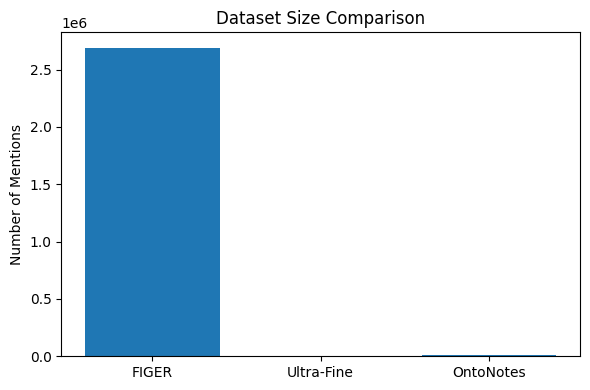

In [87]:
dataset_sizes = {
    "FIGER": len(figer["train"]),
    "Ultra-Fine": len(ultrafine["train"]),
    "OntoNotes": len(ds_onto["train"])
}

plt.figure(figsize=(6,4))
plt.bar(dataset_sizes.keys(), dataset_sizes.values())

plt.title("Dataset Size Comparison")
plt.ylabel("Number of Mentions")

plt.tight_layout()
plt.savefig("dataset_size_comparison.png", dpi=300)
plt.show()

In [93]:
from collections import Counter
import numpy as np

# FIGER
figer_labels = figer["train"]["y_str"]

figer_counter = Counter()
for l in figer_labels:
    figer_counter.update(l)

figer_lengths = np.array([len(x) for x in figer_labels])


# ULTRA FINE
ultra_labels = ultrafine["train"]["y_str"]

ultra_counter = Counter()
for l in ultra_labels:
    ultra_counter.update(l)

ultra_lengths = np.array([len(x) for x in ultra_labels])


# ONTONOTES
onto_labels = ds_onto["train"]["ner_tags"]

onto_counter = Counter()
for l in onto_labels:
    onto_counter.update(l)

onto_lengths = np.array([len(x) for x in onto_labels])

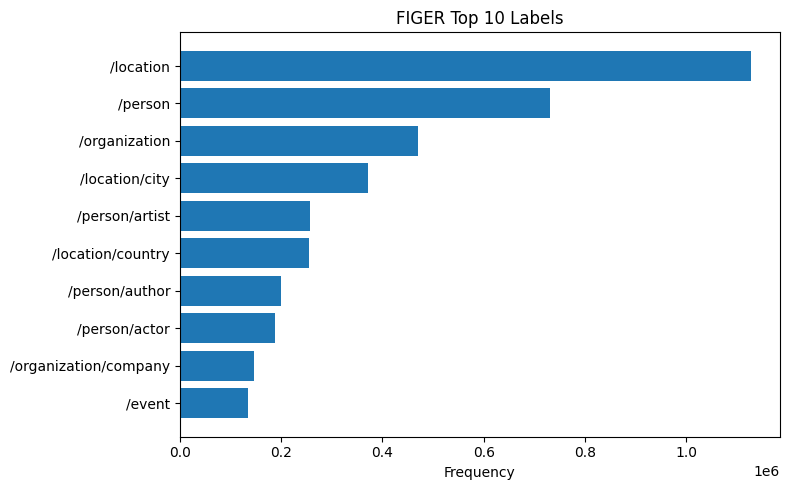

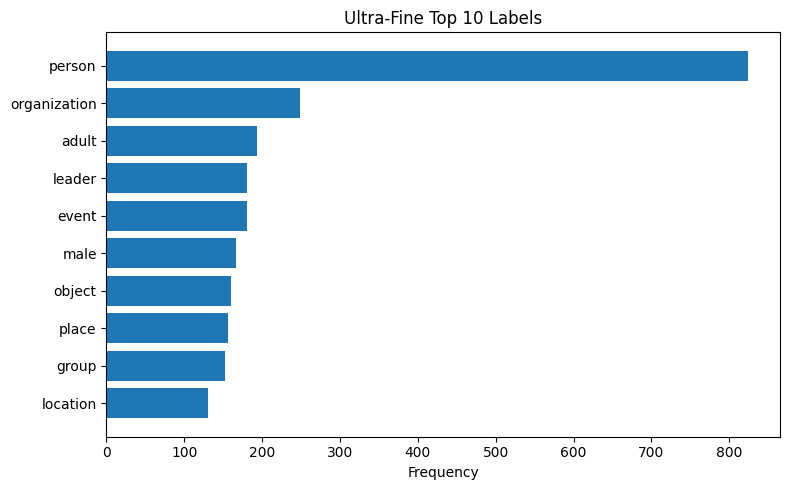

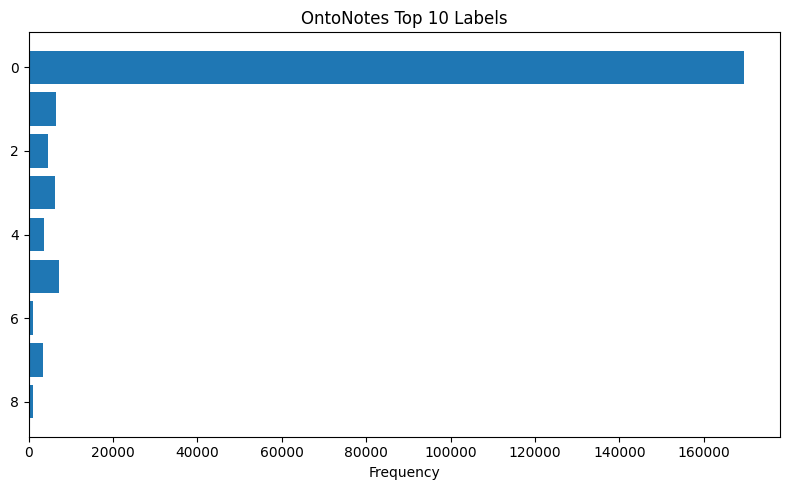

In [94]:
import matplotlib.pyplot as plt

def plot_top_labels(counter, title, filename):
    
    labels, values = zip(*counter.most_common(10))

    plt.figure(figsize=(8,5))
    plt.barh(labels, values)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Frequency")

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


plot_top_labels(figer_counter,
                "FIGER Top 10 Labels",
                "figer_top10_labels.png")

plot_top_labels(ultra_counter,
                "Ultra-Fine Top 10 Labels",
                "ultrafine_top10_labels.png")

plot_top_labels(onto_counter,
                "OntoNotes Top 10 Labels",
                "ontonotes_top10_labels.png")

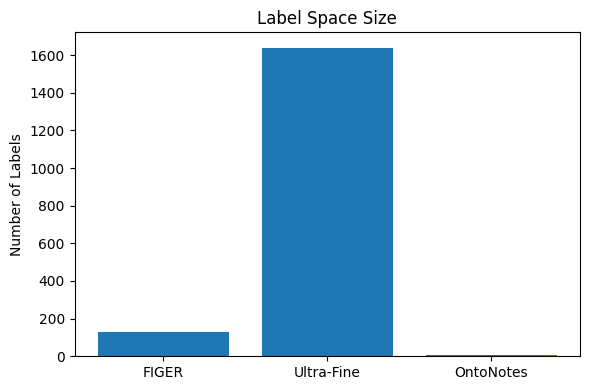

In [95]:
label_space = {
    "FIGER": len(figer_counter),
    "Ultra-Fine": len(ultra_counter),
    "OntoNotes": len(onto_counter)
}

plt.figure(figsize=(6,4))
plt.bar(label_space.keys(), label_space.values())

plt.title("Label Space Size")
plt.ylabel("Number of Labels")

plt.tight_layout()
plt.savefig("label_space_comparison.png", dpi=300)
plt.show()

In [98]:
from collections import Counter
import numpy as np

label_names = ds_onto["train"].features["ner_tags"].feature.names

onto_counter = Counter()
onto_lengths = []

for row in ds_onto["train"]:

    tags = row["ner_tags"]

    current_label = None

    for tag_id in tags:

        tag = label_names[tag_id]

        if tag.startswith("B-"):
            label = tag[2:]

            onto_counter[label] += 1
            onto_lengths.append(1)

        # I- gehört zum gleichen Entity
        # deshalb ignorieren wir es hier

onto_lengths = np.array(onto_lengths)

print("OntoNotes label space:", len(onto_counter))
print("Average labels per mention:", onto_lengths.mean())
print("Max labels per mention:", onto_lengths.max())

OntoNotes label space: 4
Average labels per mention: 1.0
Max labels per mention: 1


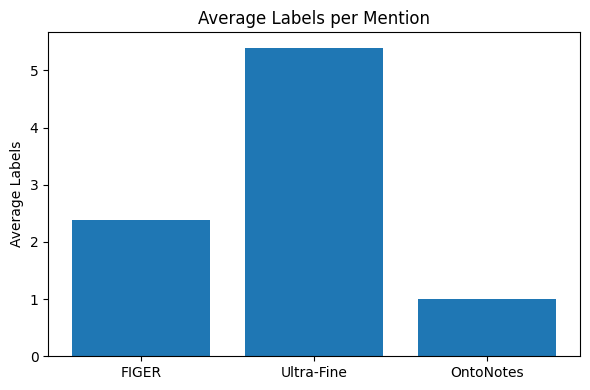

In [99]:
avg_labels = {
    "FIGER": figer_lengths.mean(),
    "Ultra-Fine": ultra_lengths.mean(),
    "OntoNotes": onto_lengths.mean()
}

plt.figure(figsize=(6,4))
plt.bar(avg_labels.keys(), avg_labels.values())

plt.title("Average Labels per Mention")
plt.ylabel("Average Labels")

plt.tight_layout()
plt.savefig("avg_labels_per_mention.png", dpi=300)
plt.show()

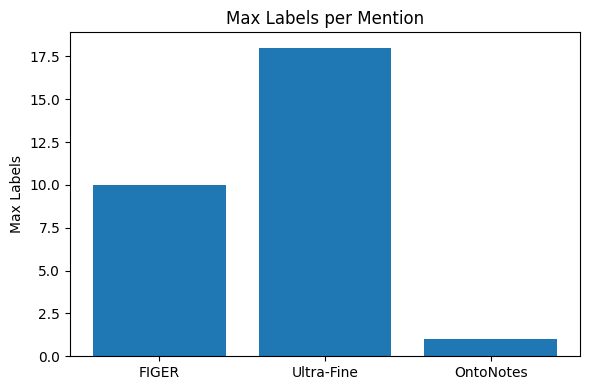

In [100]:
max_labels = {
    "FIGER": figer_lengths.max(),
    "Ultra-Fine": ultra_lengths.max(),
    "OntoNotes": onto_lengths.max()
}

plt.figure(figsize=(6,4))
plt.bar(max_labels.keys(), max_labels.values())

plt.title("Max Labels per Mention")
plt.ylabel("Max Labels")

plt.tight_layout()
plt.savefig("max_labels_per_mention.png", dpi=300)
plt.show()